# Optimization & MCDA — Weighted Scoring, Quick LP

Security teams face a recurring problem: too many candidate controls, not enough
budget, and no principled way to rank them. Stakeholders want to know *why* a
particular control was selected over another, so the ranking method must be
**explainable**.

These are not theoretical exercises. Every annual security budget cycle involves
exactly this problem: a list of initiatives competing for limited funds, each
championed by a different team, each claiming to be critical. Without a structured
framework, the loudest voice or the most recent incident wins. MCDA and optimization
provide an alternative grounded in explicit criteria and reproducible logic.

A typical security roadmap might list 15–20 candidate initiatives: endpoint
detection, MFA expansion, network segmentation, backup hardening, security
awareness training, cloud posture management, and so on. Each costs a different
amount, reduces different risks by different degrees, takes a different amount of
time to implement, and requires different skills. Choosing the best subset under a
fixed budget is a combinatorial problem, and intuition alone handles it poorly once
you pass five or six options.

This notebook walks through three complementary approaches:

1. **Multi-Criteria Decision Analysis (MCDA)** — weighted scoring across several
   criteria, with a sensitivity check on the weights.
2. **Greedy ROI selection** — pick controls in decreasing bang-for-buck order
   until the budget runs out.
3. **Linear Programming (LP)** — the relaxed 0-1 knapsack, which gives an upper
   bound on what any feasible selection can achieve.

What all three methods share is transparency. The inputs (scores, weights, costs,
risk-reduction estimates) are visible and debatable. The logic is reproducible.
And the outputs can be stress-tested by varying assumptions. This stands in sharp
contrast to the more common approach: a senior leader ranks controls by gut feel
in a spreadsheet, and everyone else reverse-engineers the rationale after the fact.

Each method answers a slightly different question. Understanding when they agree
— and when they disagree — is the real takeaway.

## Decision-Theoretic Foundations

The weighted scoring approach in this notebook has deep roots in formal decision
theory — specifically, **multiattribute utility theory** developed by Raiffa (1968)
and Keeney and Raiffa (1976). Understanding these foundations is not required to
use MCDA, but it explains *why* the method works and when it breaks down.

When a decision involves multiple attributes — cost, risk reduction, implementation
time, compliance alignment — the question is not *whether* to weight them, but
whether to weight them **explicitly** or **implicitly**. Every control selection
involves multi-attribute trade-offs. When a CISO says "EDR is more important than
SIEM," they have already assigned weights — they just haven't written them down.

Raiffa showed that if a decision-maker's preferences satisfy two behavioral axioms,
then there exists a utility function that represents those preferences as a weighted
sum over attribute scores:

$$u(C) = \sum_k w_k \, u_k(x_k)$$

**Two key axioms (Raiffa 1968; Keeney & Raiffa 1976):**

1. **Transitivity:** If you prefer A to B and B to C, you must prefer A to C.
   Violations create "money pumps" — circular preferences that vendors can exploit
   (see notebook 05).

2. **Substitutability:** If you are indifferent between two prizes in a lottery,
   swapping one for the other should not change your preference. This lets us
   replace complex multi-attribute outcomes with single-number scores.

This result is significant because it means the MCDA approach in this notebook is
not an arbitrary heuristic. When the axioms hold, weighted scoring is the *unique*
representation consistent with the decision-maker's preferences. The weights encode
the relative importance of each criterion, and the normalization ensures
commensurability across scales.

The axioms also reveal where MCDA can mislead:

- **Transitivity violations** (discussed in Chapter 0.5 under intransitive
  preferences) mean the decision-maker's implicit preferences cannot be represented
  by *any* set of consistent weights. The right response is to resolve the
  intransitivity before scoring, not to force a weighting that papers over the
  inconsistency.
- **Substitutability failures** occur when attributes interact — for example, when
  the value of compliance alignment depends on the level of risk reduction already
  achieved. These cases require more sophisticated models (multiplicative utility)
  that go beyond the additive form used here.

For most security control-selection problems, the additive model is a reasonable
starting point. The key insight from Raiffa is that weighted scoring is not merely
a convenient tool — it is the minimum formal structure needed to make multi-criteria
decisions consistently, and its limitations are precisely the limitations of the
underlying preference axioms.

The practical message: MCDA is not an arbitrary scoring exercise. It is the
simplest formal model that is *consistent* with rational multi-attribute preferences.
The weights are the hard part — not because the math demands them, but because they
force explicit trade-offs that organizations normally leave implicit.

## 1 — Setup

We use `decision-security`'s ROI selector, pandas for tabular data,
scipy's linear programming solver, and matplotlib for visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog

from decision_security.synth import make_rng
from decision_security.voi import select_controls_by_roi

rng = make_rng(42)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PRIMARY = "#1A1A1A"
ACCENT = "#E74C3C"
DARK_BG = "#34495E"
LIGHT_GRAY = "#95A5A6"
MED_GRAY = "#7F8C8D"
VERY_LIGHT = "#BDC3C7"


## 2 — MCDA: Weighted Scoring

Multi-criteria decision analysis scores each candidate control across several
dimensions — risk reduction, implementation cost, time to deploy, operational
complexity, regulatory alignment — then combines them into a single weighted score:

$$\text{score}_i = \sum_k w_k \cdot s_{ik}$$

where $w_k$ are the criteria weights (summing to 1) and $s_{ik}$ is the normalized
score of control $i$ on criterion $k$.

**Normalization matters.** Raw scores on different scales (dollars, months,
percentage risk reduction) must be mapped to a common range, typically $[0, 1]$,
before weighting. Min-max normalization is the simplest approach:

$$s_{ik} = \frac{x_{ik} - \min_k}{\max_k - \min_k}$$

The choice of normalization method can change rankings — this is not a bug but a
feature, because it forces you to decide what "better" means on each dimension.

We evaluate six candidate controls against four criteria. Three of the criteria
are "inverse" (lower raw value is better), so we name them with an `_inv` suffix
and flip them before scoring.

| Criterion | Weight | Direction |
|---|---|---|
| `risk_reduction` | 0.40 | higher is better |
| `cost_inv` | 0.30 | lower cost is better |
| `time_inv` | 0.15 | shorter implementation is better |
| `complexity_inv` | 0.15 | simpler is better |

The weights encode stakeholder priorities. A CISO focused on regulatory deadlines
might weight compliance alignment heavily; a CTO focused on operational stability
might weight implementation complexity. Making weights explicit and visible is the
primary benefit of MCDA — it transforms "I just think MFA is more important" into
a testable, debatable parameter.

> **Tip:** A practical approach to weight elicitation: ask each stakeholder to
> distribute 100 points across the criteria. Average the distributions, then show
> individual allocations alongside the average. Disagreements about weights are
> often more informative than the final ranking — they reveal where the leadership
> team lacks alignment on strategic priorities.

In [2]:
controls = [
    "MFA Rollout",
    "EDR Deployment",
    "Network Segmentation",
    "Security Awareness",
    "Patch Automation",
    "DLP Gateway",
]

# Raw scores — higher is better for risk_reduction;
# lower is better for cost, time, complexity.
raw = pd.DataFrame(
    {
        "risk_reduction": [0.35, 0.50, 0.45, 0.15, 0.40, 0.25],
        "cost_inv":       [50, 200, 180, 30, 90, 150],       # $K
        "time_inv":       [2, 6, 8, 1, 3, 5],                # months
        "complexity_inv": [2, 4, 5, 1, 3, 4],                # 1-5 scale
    },
    index=controls,
)
raw

,risk_reduction,cost_inv,time_inv,complexity_inv
MFA Rollout,0.35,50,2,2
EDR Deployment,0.50,200,6,4
Network Segmentation,0.45,180,8,5
Security Awareness,0.15,30,1,1
Patch Automation,0.40,90,3,3
DLP Gateway,0.25,150,5,4


In [3]:
def normalize_mcda(df):
    """Min-max normalise each column to [0, 1].
    Columns ending in '_inv' are flipped so that lower raw = higher score."""
    normed = pd.DataFrame(index=df.index)
    for col in df.columns:
        lo, hi = df[col].min(), df[col].max()
        span = hi - lo if hi != lo else 1.0
        if col.endswith("_inv"):
            normed[col] = (hi - df[col]) / span
        else:
            normed[col] = (df[col] - lo) / span
    return normed


normed = normalize_mcda(raw)
normed.round(3)

,risk_reduction,cost_inv,time_inv,complexity_inv
MFA Rollout,0.571,0.882,0.857,0.75
EDR Deployment,1.000,0.000,0.286,0.25
Network Segmentation,0.857,0.118,0.000,0.00
Security Awareness,0.000,1.000,1.000,1.00
Patch Automation,0.714,0.647,0.714,0.50
DLP Gateway,0.286,0.294,0.429,0.25


In [4]:
weights = np.array([0.40, 0.30, 0.15, 0.15])
assert np.isclose(weights.sum(), 1.0), "Weights must sum to 1"

normed["weighted_score"] = normed.values @ weights
normed["rank"] = normed["weighted_score"].rank(ascending=False).astype(int)
normed.sort_values("rank")

,risk_reduction,cost_inv,time_inv,complexity_inv,weighted_score,rank
MFA Rollout,0.571429,0.882353,0.857143,0.75,0.734349,1
Patch Automation,0.714286,0.647059,0.714286,0.50,0.661975,2
Security Awareness,0.000000,1.000000,1.000000,1.00,0.600000,3
EDR Deployment,1.000000,0.000000,0.285714,0.25,0.480357,4
Network Segmentation,0.857143,0.117647,0.000000,0.00,0.378151,5
DLP Gateway,0.285714,0.294118,0.428571,0.25,0.304307,6


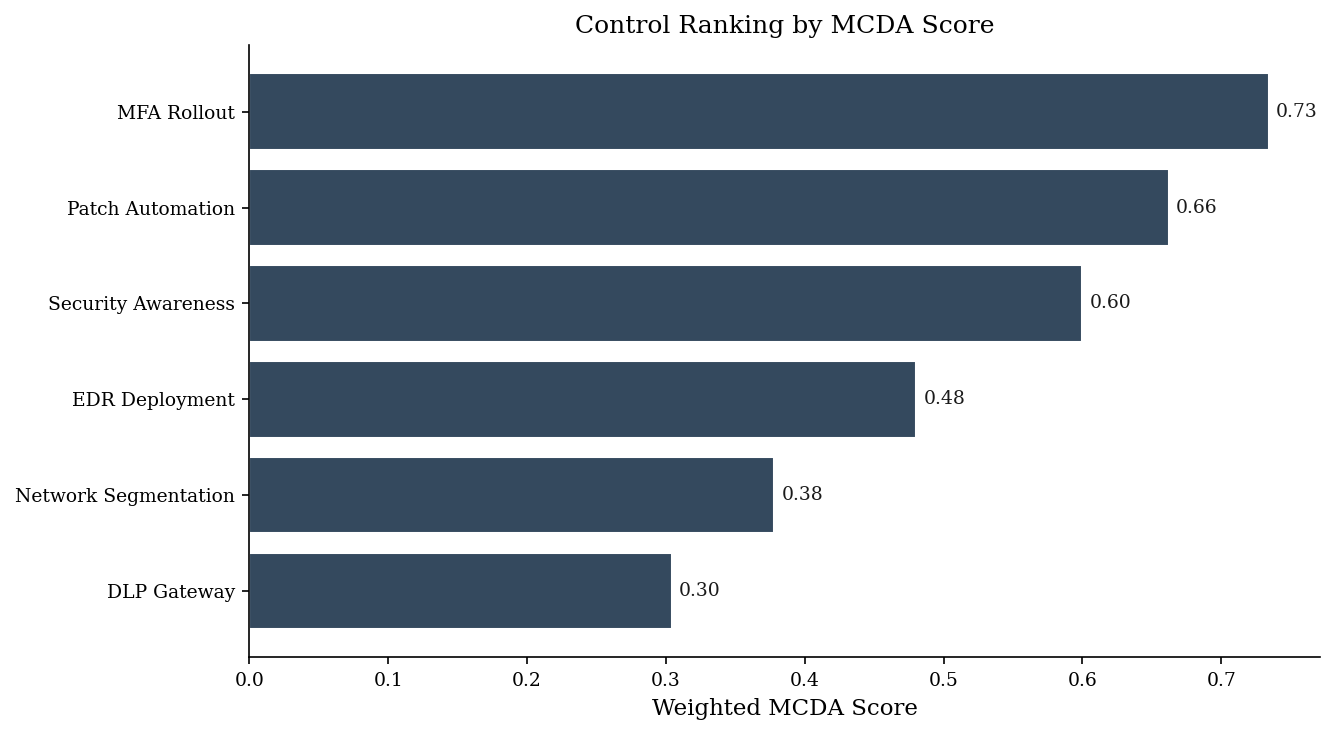

In [5]:
sorted_df = normed.sort_values('weighted_score', ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(sorted_df.index, sorted_df['weighted_score'], color=DARK_BG, edgecolor='white')
for i, (idx_name, row) in enumerate(sorted_df.iterrows()):
    ax.text(row['weighted_score'] + 0.005, i, f'{row["weighted_score"]:.2f}',
            va='center', fontsize=9, color=PRIMARY)
ax.set_xlabel('Weighted MCDA Score')
ax.set_title('Control Ranking by MCDA Score')
plt.tight_layout()
plt.show()

## 3 — Sensitivity Analysis

Any ranking that depends on weights should be stress-tested. **Sensitivity analysis**
asks: how much would a weight need to change before the top-ranked control loses
its position? These critical thresholds are called **flip points**, and they reveal
whether a ranking is robust or fragile.

If swinging the cost weight from 0.25 to 0.30 flips the top two controls, the
ranking is sensitive and the weight choice deserves more scrutiny. If the top
control dominates across all plausible weight ranges, you can proceed with
confidence.

We vary the `cost_inv` weight from 0.10 to 0.60, redistributing the remaining
weight among the other three criteria in the same proportions they had originally.
The code identifies exact flip points where rank swaps occur.

In practice, presenting sensitivity results to stakeholders is as valuable as the
ranking itself. When a decision-maker sees that their preferred control only wins
under a narrow weight range, the conversation shifts from "which control is best?"
to "how much do we actually value this criterion?" — which is the right question
to be asking.

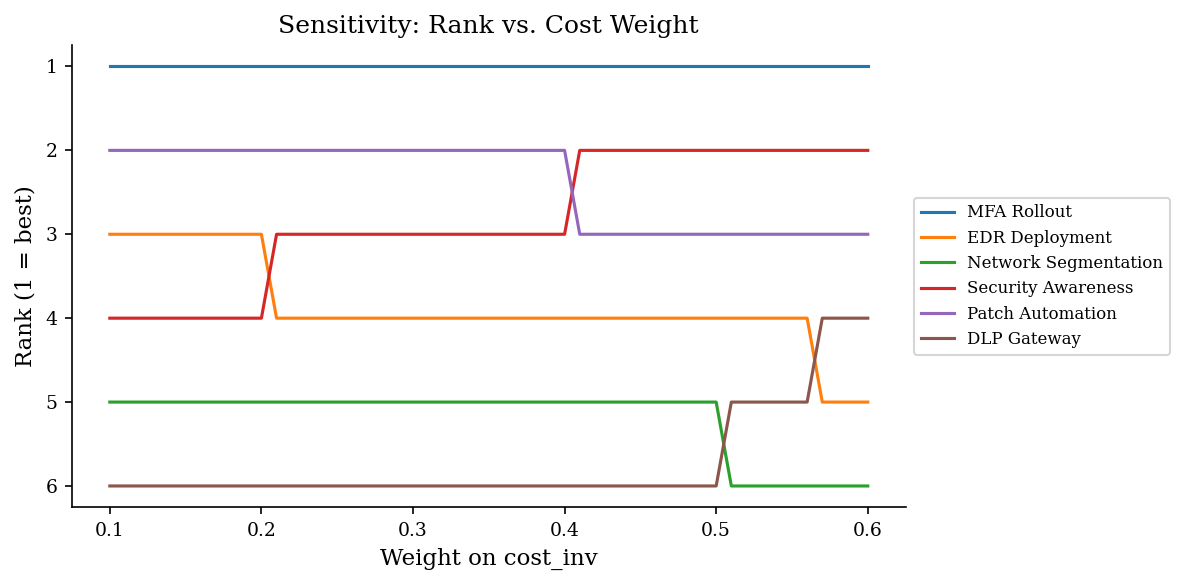

In [6]:
base_weights = np.array([0.40, 0.30, 0.15, 0.15])
cost_idx = 1  # cost_inv is the second criterion

cost_range = np.arange(0.10, 0.61, 0.01)
rank_history = {c: [] for c in controls}

for cw in cost_range:
    w = base_weights.copy()
    remaining = 1.0 - cw
    others_sum = base_weights.sum() - base_weights[cost_idx]
    for j in range(len(w)):
        if j == cost_idx:
            w[j] = cw
        else:
            w[j] = base_weights[j] / others_sum * remaining
    scores = normalize_mcda(raw).values @ w
    order = (-scores).argsort()
    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(order) + 1)
    for i, c in enumerate(controls):
        rank_history[c].append(ranks[i])

fig, ax = plt.subplots(figsize=(8, 4))
for c in controls:
    ax.plot(cost_range, rank_history[c], label=c)
ax.set_xlabel("Weight on cost_inv")
ax.set_ylabel("Rank (1 = best)")
ax.set_title("Sensitivity: Rank vs. Cost Weight")
ax.invert_yaxis()
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

In [7]:
# Identify flip points — cost weights where adjacent ranks swap
print("Flip points (cost_inv weight where a rank swap occurs):")
prev_ranks = {c: rank_history[c][0] for c in controls}
for step, cw in enumerate(cost_range[1:], 1):
    for c in controls:
        if rank_history[c][step] != prev_ranks[c]:
            print(f"  cost_w={cw:.2f}: {c} moved from rank {prev_ranks[c]} to {rank_history[c][step]}")
    prev_ranks = {c: rank_history[c][step] for c in controls}

Flip points (cost_inv weight where a rank swap occurs):
  cost_w=0.21: EDR Deployment moved from rank 3 to 4
  cost_w=0.21: Security Awareness moved from rank 4 to 3
  cost_w=0.41: Security Awareness moved from rank 3 to 2
  cost_w=0.41: Patch Automation moved from rank 2 to 3
  cost_w=0.51: Network Segmentation moved from rank 5 to 6
  cost_w=0.51: DLP Gateway moved from rank 6 to 5
  cost_w=0.57: EDR Deployment moved from rank 4 to 5
  cost_w=0.57: DLP Gateway moved from rank 5 to 4


## 4 — Greedy ROI Selection

When the goal is simply to maximize risk reduction under a budget constraint, a
**greedy approach** is fast and intuitive: compute each control's risk reduction
per dollar (ROI), sort descending, and select controls in order until the budget
is exhausted.

This works well when controls are roughly independent and similarly sized. It is
the same logic behind the fractional knapsack solution in algorithms courses, and
it produces optimal results when items can be partially selected. For indivisible
controls (you either deploy MFA or you don't), greedy is a good heuristic but not
guaranteed optimal — though in practice it is usually within a few percent of the
true optimum.

Where greedy fails is when a high-ROI but expensive control consumes most of the
budget, preventing two medium-ROI controls that together would deliver more total
reduction. The classic knapsack counterexample applies directly: sometimes skipping
the "best" item and packing two smaller ones yields a better total. We compare
greedy output to LP-optimal output below to show when and how much this matters.

We use `select_controls_by_roi` from `decision-security` with a **$300K budget**.

In [8]:
deltas = raw["risk_reduction"].values
costs = raw["cost_inv"].values * 1_000  # convert $K to $
budget = 300_000

chosen_idx, total_cost, total_delta = select_controls_by_roi(deltas, costs, budget)

roi_table = pd.DataFrame(
    {
        "control": [controls[i] for i in chosen_idx],
        "risk_reduction": [deltas[i] for i in chosen_idx],
        "cost_K": [costs[i] / 1_000 for i in chosen_idx],
        "roi": [deltas[i] / costs[i] * 1_000 for i in chosen_idx],
    }
)
roi_table["cumulative_cost_K"] = roi_table["cost_K"].cumsum()
roi_table["cumulative_reduction"] = roi_table["risk_reduction"].cumsum()

print(f"Budget: ${budget:,.0f}")
print(f"Spent:  ${total_cost:,.0f}  |  Risk reduced: {total_delta:.2f}")
roi_table

Budget: $300,000
Spent:  $170,000  |  Risk reduced: 0.90


,control,risk_reduction,cost_K,roi,cumulative_cost_K,cumulative_reduction
0,MFA Rollout,0.35,50.0,0.007000,50.0,0.35
1,Security Awareness,0.15,30.0,0.005000,80.0,0.50
2,Patch Automation,0.40,90.0,0.004444,170.0,0.90


## 5 — MCDA vs. ROI: When They Disagree

MCDA and greedy ROI can produce **different** selections because they optimize
different objectives. ROI selection optimizes a single dimension — risk reduction
per dollar. MCDA balances multiple concerns. When they diverge, it usually means
the top-ROI control scores poorly on a dimension that MCDA weights care about
(e.g., it is fast and cheap but creates heavy operational burden).

| Aspect | MCDA | Greedy ROI |
|---|---|---|
| Objective | Highest *overall* score across criteria | Maximum risk reduction per dollar |
| Budget awareness | Not inherently budget-constrained | Stops at the budget cap |
| Criteria breadth | Considers time, complexity, etc. | Only risk reduction and cost |
| Explainability | Transparent weights; auditable | Simple ratio; easy to verify |

Neither method is universally better:

- **MCDA** when stakeholders care about *more than just cost and risk* — for example,
  implementation speed, operational complexity, or regulatory alignment.
- **ROI** when the decision is purely financial and the single objective is clear:
  maximize risk reduction subject to a hard budget.
- **Both together** as a sanity check: if a control ranks highly on MCDA but is
  absent from the ROI selection, investigate why (often it is expensive relative
  to its risk reduction alone).

A useful heuristic: if the MCDA ranking and the ROI ranking agree on the top three
controls, you have a robust selection regardless of method. If they disagree
significantly, the disagreement itself is the most valuable output — it tells you
exactly which trade-offs need executive attention rather than analyst judgment.

## 6 — Linear Programming: Relaxed 0-1 Knapsack

For larger portfolios or tighter constraints, **linear programming (LP)** provides
a rigorous alternative to greedy heuristics. The control selection problem maps
directly to a **0-1 knapsack** formulation:

$$\max \sum_i v_i \, x_i \quad \text{subject to} \quad \sum_i c_i \, x_i \leq B, \quad x_i \in \{0, 1\}$$

where $v_i$ is the risk reduction of control $i$, $c_i$ is its cost, $B$ is the
total budget, and $x_i$ indicates whether control $i$ is selected.

The LP relaxation allows $x_i$ to take any value in $[0, 1]$, which provides an
**upper bound** on the achievable risk reduction and is solvable in milliseconds.
Comparing the relaxed solution to the greedy integer solution tells you how much
optimality you are leaving on the table — often very little for security portfolios
with moderate numbers of controls.

You can also add side constraints beyond budget: maximum headcount for
implementation, minimum coverage of certain risk categories, or mutual exclusivity
(choose cloud WAF *or* on-prem WAF, not both). Each constraint is an additional
row in the LP matrix.

`scipy.optimize.linprog` minimizes, so we negate risk reduction to maximize it.

In [9]:
n = len(controls)

# Objective: minimise -delta (= maximise delta)
c_obj = -deltas

# Constraint: total cost <= budget
A_ub = [costs]           # one row
b_ub = [budget]

# Bounds: 0 <= x_i <= 1  (LP relaxation)
bounds = [(0, 1)] * n

result = linprog(c_obj, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
assert result.success, f"LP failed: {result.message}"

lp_reduction = -result.fun
lp_allocation = pd.Series(result.x, index=controls).round(4)

print(f"LP relaxation — max risk reduction: {lp_reduction:.4f}")
print(f"Greedy ROI    — risk reduction:     {total_delta:.4f}")
print(f"Gap:          {lp_reduction - total_delta:.4f}")
print()
print("Allocation (1.0 = fully selected, fractional = partially):")
lp_allocation

LP relaxation — max risk reduction: 1.2250
Greedy ROI    — risk reduction:     0.9000
Gap:          0.3250

Allocation (1.0 = fully selected, fractional = partially):


MFA Rollout             1.0000
EDR Deployment          0.0000
Network Segmentation    0.7222
Security Awareness      1.0000
Patch Automation        1.0000
DLP Gateway             0.0000
dtype: float64

If the LP solution is all-integer, the greedy result is already optimal.
A fractional entry indicates the LP needed to "split" a control to fill the
budget exactly — the greedy approach either includes or excludes it. The gap
between LP-relaxed and greedy tells you the cost of indivisibility.

## 7 — Efficient Frontier: Budget vs. Risk Reduction

Varying the budget constraint and solving repeatedly traces an **efficient frontier**:
the maximum achievable risk reduction at each budget level. This curve typically
shows diminishing returns — the first $500K buys substantially more risk reduction
than the next $500K — and provides a powerful communication tool for executive
audiences.

The frontier answers two practical questions:

- **Where does the curve flatten?** Beyond this budget, you are buying increasingly
  marginal improvements. This is the natural "enough" point for budget negotiations.
- **Are we on the frontier?** If your current portfolio sits below the curve, you
  are leaving risk reduction on the table with the same spend. Reallocation beats
  new budget.

The frontier also answers questions that boards and CFOs routinely ask: "What is
the marginal value of an additional \$100K in security budget?" and "At what
spending level do we hit diminishing returns?" Having a data-backed answer changes
the conversation from "trust me" to "here is the trade-off curve."

Any point *below* the frontier represents an inefficient allocation — you could get
the same risk reduction for less money, or more reduction for the same money, by
switching to a frontier portfolio. If your current control set falls well below the
curve, that is a strong signal to reallocate before requesting additional budget.

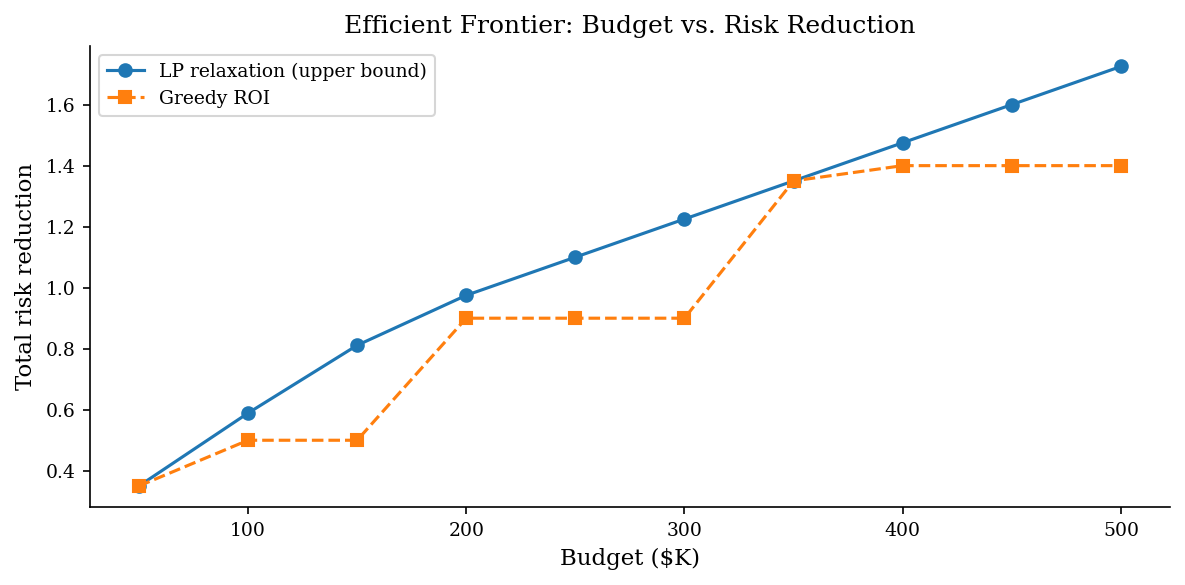

In [10]:
budgets = np.arange(50_000, 500_001, 50_000)
lp_reductions = []
greedy_reductions = []

for b in budgets:
    # LP relaxation
    res = linprog(c_obj, A_ub=[costs], b_ub=[b], bounds=bounds, method="highs")
    lp_reductions.append(-res.fun if res.success else np.nan)

    # Greedy
    _, _, g_delta = select_controls_by_roi(deltas, costs, b)
    greedy_reductions.append(g_delta)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(budgets / 1_000, lp_reductions, "o-", label="LP relaxation (upper bound)")
ax.plot(budgets / 1_000, greedy_reductions, "s--", label="Greedy ROI")
ax.set_xlabel("Budget ($K)")
ax.set_ylabel("Total risk reduction")
ax.set_title("Efficient Frontier: Budget vs. Risk Reduction")
ax.legend()
plt.tight_layout()
plt.show()

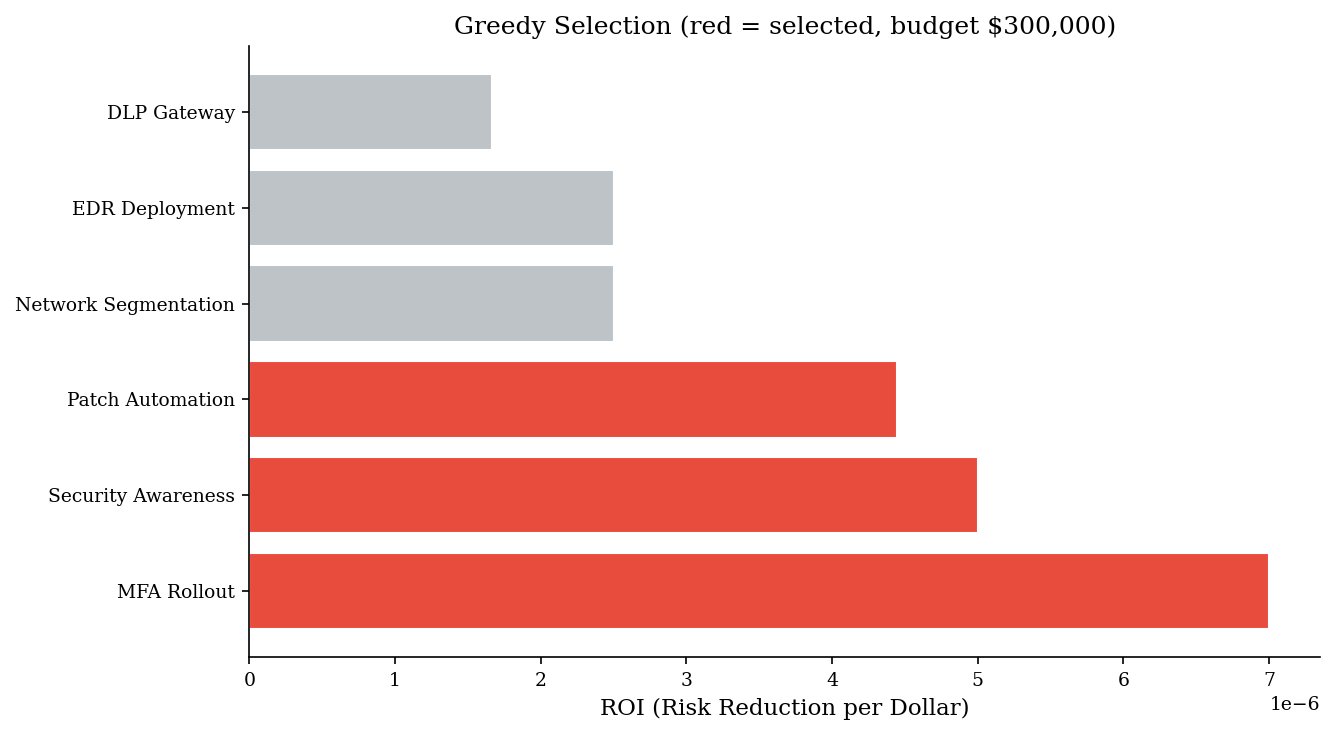

In [11]:
roi_vals = deltas / costs
order = np.argsort(roi_vals)[::-1]
bar_colors = [ACCENT if i in chosen_idx else VERY_LIGHT for i in order]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh([controls[i] for i in order],
        [roi_vals[i] for i in order],
        color=bar_colors, edgecolor='white')
ax.set_xlabel('ROI (Risk Reduction per Dollar)')
ax.set_title(f'Greedy Selection (red = selected, budget ${budget:,.0f})')
plt.tight_layout()
plt.show()

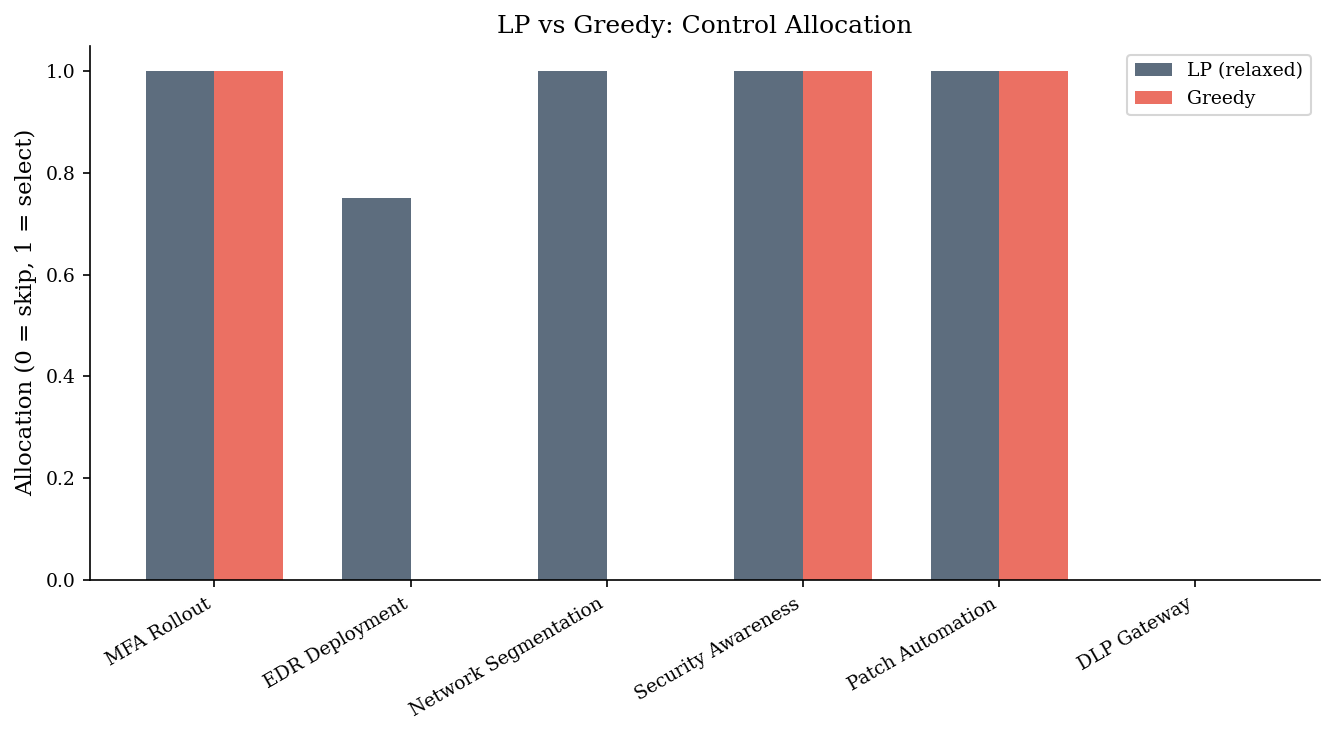

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(n)
width = 0.35

greedy_alloc = np.zeros(n)
for ci in chosen_idx:
    greedy_alloc[ci] = 1.0

ax.bar(x_pos - width/2, res.x, width, label='LP (relaxed)', color=DARK_BG, alpha=0.8)
ax.bar(x_pos + width/2, greedy_alloc, width, label='Greedy', color=ACCENT, alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(controls, rotation=30, ha='right')
ax.set_ylabel('Allocation (0 = skip, 1 = select)')
ax.set_title('LP vs Greedy: Control Allocation')
ax.legend()
plt.tight_layout()
plt.show()

Notice how the curve flattens: after a certain budget level, adding more money
buys very little additional risk reduction. This is the classic diminishing-returns
pattern and a powerful visual for communicating budget trade-offs to leadership.
The gap between the LP relaxation (upper bound) and the greedy integer solution
shows how much optimality the heuristic leaves on the table.

## 8 — Pitfalls

**Weights must sum to 1.**
If they do not, the weighted score is on an arbitrary scale and comparisons
across analyses become meaningless. Always normalize.

**Incomparable scales.**
Cost in dollars and complexity on a 1–5 ordinal scale cannot be summed directly.
Normalization (min-max, z-score, or rank-based) is mandatory *before* applying
weights. The choice of normalization method itself affects results — document it.

**Criteria washing.**
Adding redundant or highly correlated criteria inflates the importance of the
dimension they represent. If "cost" and "TCO" are both included at equal weight,
cost effectively gets double the influence. Each criterion should capture a
distinct concern — audit your criteria for independence before you set weights.

**Ignoring interactions.**
Both MCDA and greedy selection treat controls independently. In reality, deploying
network segmentation changes the marginal value of east-west detection.
Portfolio-aware methods (covered in later chapters) handle this, but for a first
pass, independence is a reasonable simplifying assumption.

**Optimizing the wrong objective.**
A technically optimal portfolio that ignores political feasibility, implementation
sequencing, or organizational capacity will not survive contact with reality. Treat
optimization output as a starting point for discussion, not a final answer.

> **Note:** Both MCDA and LP are deterministic methods applied to uncertain inputs.
> The risk-reduction estimates, cost figures, and criteria scores feeding these
> models are themselves uncertain. Robust approaches — running the optimization
> across many Monte Carlo samples of the inputs — are covered in later chapters.
> For now, the key insight is that *structured* prioritization, even with imperfect
> inputs, consistently outperforms unstructured intuition.